Realiza un programa en jupyter con python, en el cual haciendo uso del RETO DEL RELOJ (identificando cualquier hora analógica), me responda la hora de manera literal 

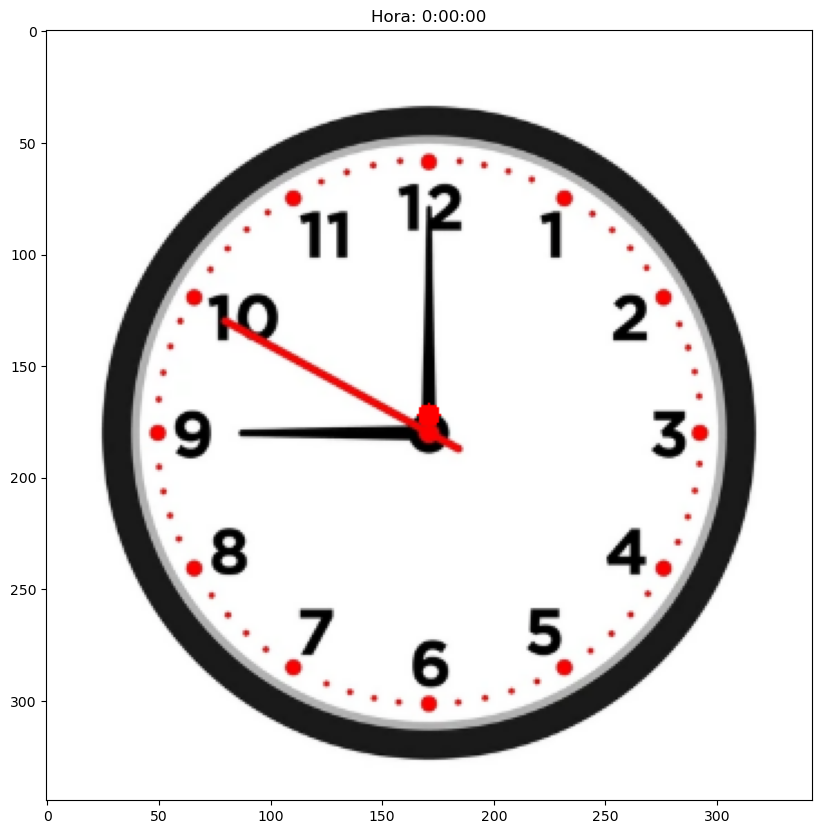

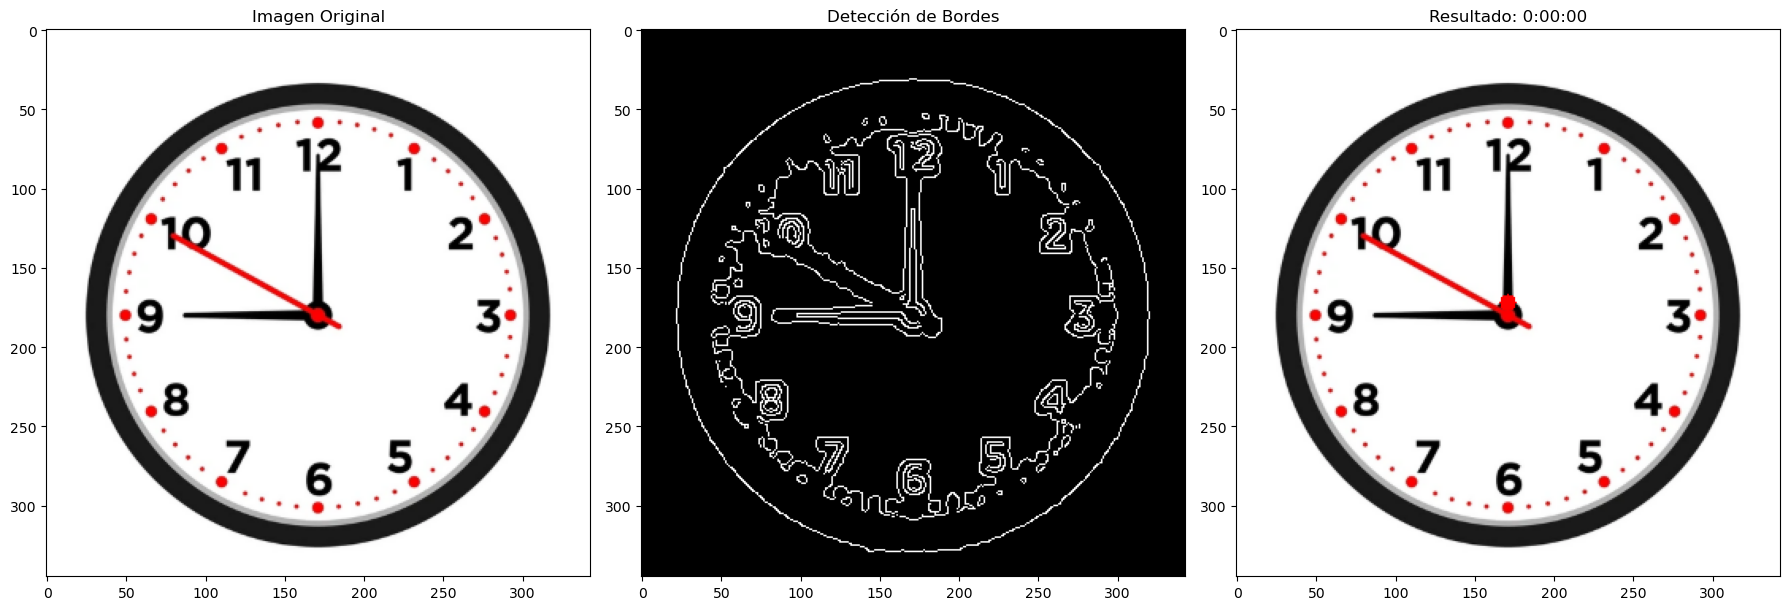

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Cargar imagen
imagen_bgr = cv2.imread('img/reloj4.png')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

# Preprocesamiento para mejorar la detección
gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)

# Detector de bordes más sensible para captar la manecilla de segundos
bordes = cv2.Canny(gris, 30, 150)

# Encontrar el centro del reloj (asumimos que está en el centro de la imagen)
centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2

# Detección de círculos para encontrar el contorno del reloj y refinar el centro
circulos = cv2.HoughCircles(
    gris, 
    cv2.HOUGH_GRADIENT, 
    dp=1, 
    minDist=100,
    param1=50, 
    param2=30,
    minRadius=min(imagen_bgr.shape) // 4,  # Ajustar según el tamaño del reloj
    maxRadius=min(imagen_bgr.shape) // 2
)

# Si encontramos círculos, usar el más grande como referencia para el centro del reloj
if circulos is not None:
    circulos = np.uint16(np.around(circulos))
    mejor_circulo = circulos[0, 0]  # Tomar el primer círculo
    centro_x, centro_y = mejor_circulo[0], mejor_circulo[1]

# Detección de líneas con parámetros más sensibles
lineas = cv2.HoughLinesP(
    bordes, 
    rho=1, 
    theta=np.pi/180, 
    threshold=40,  # Umbral más bajo para detectar líneas más débiles (segundero)
    minLineLength=30,  # Líneas más cortas (para detectar el segundero)
    maxLineGap=20  # Mayor tolerancia a interrupciones
)

def calcular_angulo(x1, y1, x2, y2, centro_x, centro_y):
    """Calcula el ángulo de una línea respecto al centro del reloj"""
    # Determinar cuál extremo está más lejos del centro
    dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
    dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
    
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    
    # Calcular ángulo (0 grados en la posición de las 12 en punto)
    angulo = np.degrees(np.arctan2(dy, dx))
    angulo = (90 - angulo) % 360
    return angulo

def clasificar_manecilla(longitud, grosor, radio_reloj):
    """Clasifica una línea como horario, minutero o segundero basado en características"""
    longitud_relativa = longitud / radio_reloj
    
    # Ajustar estos umbrales según las características del reloj
    if longitud_relativa < 0.5:
        return "horario"
    elif longitud_relativa < 0.8 and grosor > 3:
        return "minutero"
    elif longitud_relativa > 0.7:
        return "segundero"
    else:
        return "desconocido"

# Estimar el radio del reloj
radio_reloj = min(imagen_bgr.shape) // 3  # Una estimación aproximada
if circulos is not None:
    radio_reloj = mejor_circulo[2]  # Radio del círculo detectado

# Contenedores para las manecillas
manecillas = {
    "horario": None,
    "minutero": None,
    "segundero": None
}

if lineas is not None:
    # Para almacenar todas las posibles manecillas
    candidatos = []
    
    # Procesar todas las líneas detectadas
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        
        # Calcular características de la línea
        longitud = np.hypot(x2 - x1, y2 - y1)
        distancia_centro_1 = np.hypot(x1 - centro_x, y1 - centro_y)
        distancia_centro_2 = np.hypot(x2 - centro_x, y2 - centro_y)
        
        # Verificar si la línea pasa cerca del centro
        min_distancia_centro = min(distancia_centro_1, distancia_centro_2)
        
        # Solo considerar líneas que pasen cerca del centro
        if min_distancia_centro < radio_reloj * 0.2:
            # Calcular el grosor estimado de la línea analizando píxeles cercanos
            # (simplificado: usamos la longitud como proxy)
            grosor = 1
            if longitud > radio_reloj * 0.6:
                pts = np.array([[x1, y1], [x2, y2]])
                mask = np.zeros_like(gris)
                cv2.line(mask, (x1, y1), (x2, y2), 255, 5)
                pixels = cv2.countNonZero(mask)
                grosor = pixels / longitud if longitud > 0 else 1
            
            angulo = calcular_angulo(x1, y1, x2, y2, centro_x, centro_y)
            
            candidatos.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo,
                'grosor': grosor,
                'distancia_centro': min_distancia_centro
            })
    
    # Ordenar candidatos por longitud
    candidatos.sort(key=lambda x: x['longitud'])
    
    # Filtrar candidatos que son muy similares (probablemente el mismo elemento)
    candidatos_filtrados = []
    for candidato in candidatos:
        # Comprobar si este ángulo ya está cubierto
        es_duplicado = False
        for c in candidatos_filtrados:
            if abs(c['angulo'] - candidato['angulo']) < 5 or abs(c['angulo'] - candidato['angulo']) > 355:
                es_duplicado = True
                # Quedarse con el que tenga mejor "puntuación" (más cerca del centro y más largo)
                if candidato['distancia_centro'] < c['distancia_centro'] * 0.8:
                    candidatos_filtrados.remove(c)
                    candidatos_filtrados.append(candidato)
                break
        
        if not es_duplicado:
            candidatos_filtrados.append(candidato)
    
    # Clasificar manecillas según longitud relativa y otros criterios
    # En general: horario (más corto), minutero (medio), segundero (más largo y delgado)
    if len(candidatos_filtrados) >= 2:
        # Si solo tenemos dos manecillas, asumimos horario y minutero
        if len(candidatos_filtrados) == 2:
            candidatos_filtrados.sort(key=lambda x: x['longitud'])
            manecillas["horario"] = candidatos_filtrados[0]
            manecillas["minutero"] = candidatos_filtrados[1]
        else:
            # Tenemos 3 o más candidatos
            # Clasificar por longitud relativa y grosor
            for candidato in candidatos_filtrados:
                tipo = clasificar_manecilla(candidato['longitud'], candidato['grosor'], radio_reloj)
                if tipo != "desconocido" and manecillas[tipo] is None:
                    manecillas[tipo] = candidato
            
            # Si aún faltan manecillas, asignarlas por longitud
            faltantes = [k for k, v in manecillas.items() if v is None]
            if faltantes:
                restantes = [c for c in candidatos_filtrados if all(c != manecillas[k] for k in manecillas if manecillas[k] is not None)]
                restantes.sort(key=lambda x: x['longitud'])
                
                # Horario (más corto), minutero (medio), segundero (más largo)
                for idx, tipo in enumerate(["horario", "minutero", "segundero"]):
                    if tipo in faltantes and idx < len(restantes):
                        manecillas[tipo] = restantes[idx]

# Crear imagen de resultado
imagen_resultado = imagen_rgb.copy()
cv2.circle(imagen_resultado, (centro_x, centro_y), 5, (255, 0, 0), -1)  # Marcar centro

# Dibujar manecillas y calcular hora
hora, minutos, segundos = 0, 0, 0

colores = {
    "horario": (0, 0, 255),    # Rojo
    "minutero": (0, 255, 0),   # Verde
    "segundero": (255, 0, 0)   # Azul
}

for tipo, manecilla in manecillas.items():
    if manecilla is not None:
        x1, y1, x2, y2 = manecilla['puntos']
        cv2.line(imagen_resultado, (x1, y1), (x2, y2), colores[tipo], 3)
        
        if tipo == "horario":
            hora = (manecilla['angulo'] / 30) % 12
            hora = int(hora)
            if abs((manecilla['angulo'] / 30) % 12 - hora) > 0.5:
                hora = (hora + 1) % 12
            if hora == 0:
                hora = 12
                
        elif tipo == "minutero":
            minutos = int((manecilla['angulo'] / 6) % 60)
            
        elif tipo == "segundero":
            segundos = int((manecilla['angulo'] / 6) % 60)

# Mostrar resultados
plt.figure(figsize=(12, 10))
plt.imshow(imagen_resultado)
plt.title(f'Hora: {hora}:{minutos:02d}:{segundos:02d}')
plt.show()

# También mostrar las etapas de procesamiento para debugging
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(imagen_rgb)
axes[0].set_title('Imagen Original')
axes[1].imshow(bordes, cmap='gray')
axes[1].set_title('Detección de Bordes')
axes[2].imshow(imagen_resultado)
axes[2].set_title(f'Resultado: {hora}:{minutos:02d}:{segundos:02d}')
plt.tight_layout()
plt.show()
